In [81]:
import pandas as pd
import os
from matplotlib import pyplot as plt

In [82]:
subject_id = 902
session_number = 2

# Calculate and plot the middle position

In [83]:
joystick_data = pd.read_csv('/Users/kenneth.van.der.zee/Documents/phd_1_task/experiment_output/debug/joystick_calibration/central_calibration_output_sub-902_session-02_2024-07-04_09-39-22.csv' ,sep=';')#os.path.join('Users','kenneth.van.der.zee','Documents','phd_1_task','experiment_output','debug','joystick_calibration','central_calibration_output_sub-902_session-02_2024-07-04_09-39-22.csv'), sep=';')

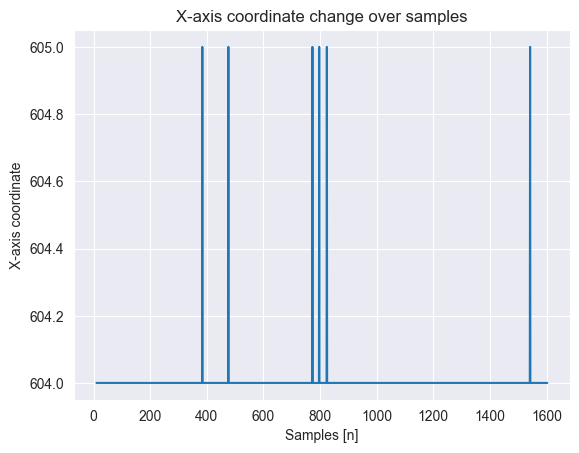

In [84]:
plt.plot(joystick_data['time'], joystick_data['location_y'])
plt.xlabel('Samples [n]')
plt.ylabel('X-axis coordinate')
plt.title('X-axis coordinate change over samples')
plt.show()

In [85]:
joystick_middle_location = joystick_data['location_y'].mean()

print(joystick_data['location_y'].max())
print(joystick_data['location_y'].min())
print(joystick_middle_location)

605
604
604.0037641154329


# Calculate and plot the forward and backward positions

In [86]:
joystick_data = pd.read_csv('/Users/kenneth.van.der.zee/Documents/phd_1_task/experiment_output/debug/joystick_calibration/joystick_output_sub-902_session-02_dummy_2024-07-04_09-38-56.csv', sep=';')#os.path.join('Users','kenneth.van.der.zee','Documents','phd_1_task','experiment_output','debug','joystick_calibration','extremities_calibration_output_sub-902_session-02_2024-07-04_09-39-22.csv'), sep=';')

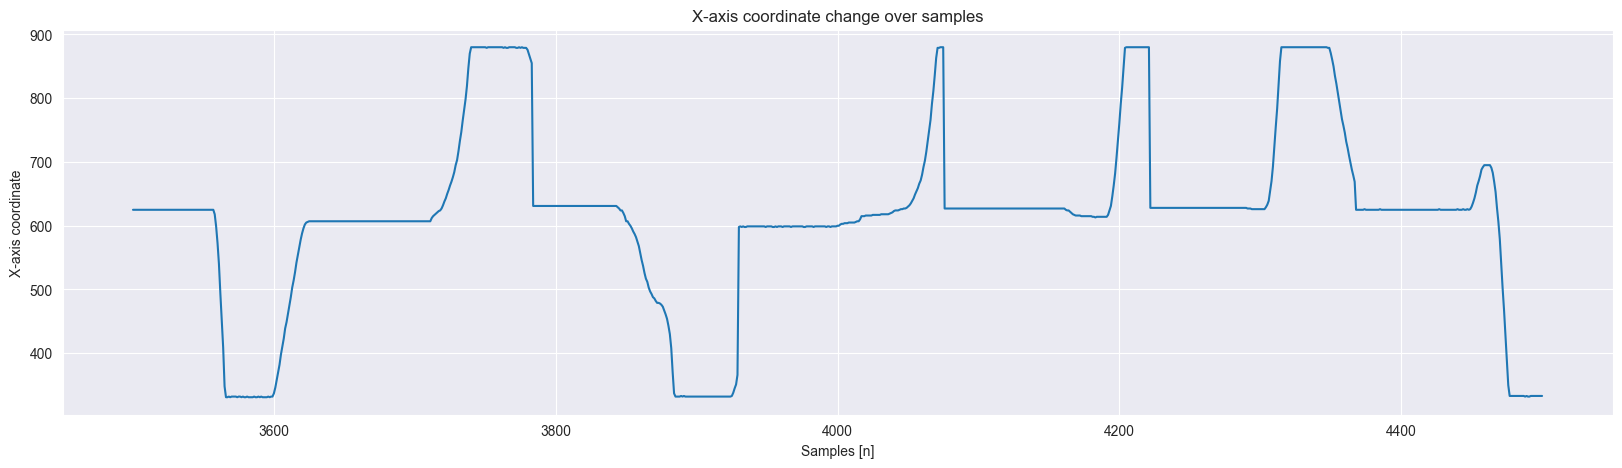

In [87]:
plt.subplots(figsize=(20, 5))
filtered_joystick_data = joystick_data[(joystick_data['datapoint'] >= 3500) & (joystick_data['datapoint'] <= 4500)]

plt.plot(filtered_joystick_data['datapoint'], filtered_joystick_data['location_y'])
plt.xlabel('Samples [n]')
plt.ylabel('X-axis coordinate')
plt.title('X-axis coordinate change over samples')
plt.show()

In [88]:
joystick_forward_position = joystick_data['location_y'].max()
joystick_backward_position = joystick_data['location_y'].min()

joystick_forward_threshold = joystick_middle_location + 0.7 * (joystick_forward_position - joystick_middle_location)
joystick_backward_threshold = joystick_middle_location - 0.7 * (joystick_middle_location - joystick_backward_position)

print(joystick_middle_location, joystick_forward_threshold, joystick_backward_threshold)

604.0037641154329 804.9011292346298 411.50112923462984


# Calculate the refresh rate

In [89]:
# Step 1: Calculate the intervals between consecutive timepoints
joystick_data['interval'] = joystick_data['timepoint'].diff()

# Step 2: Compute the refresh rate for each interval (refresh rate = 1 / interval)
# We will skip the first NaN value resulting from the diff()
joystick_data = joystick_data.dropna()
joystick_data['refresh_rate'] = 1 / joystick_data['interval']

# Step 3: Calculate the average refresh rate
average_refresh_rate = joystick_data['refresh_rate'].mean()

# Step 4: Determine the variation in the refresh rate (standard deviation)
refresh_rate_standard_deviation = joystick_data['refresh_rate'].std()

print(average_refresh_rate, refresh_rate_standard_deviation)

121.07601348927558 19.315563652024437


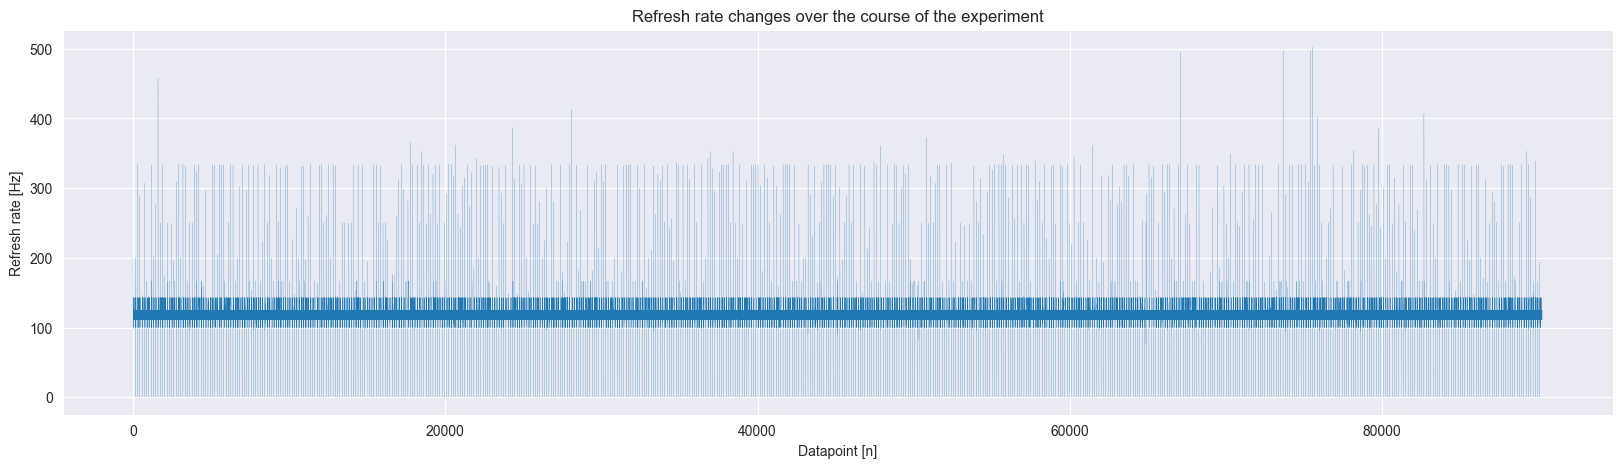

In [90]:
plt.subplots(figsize=(20, 5))
plt.plot(joystick_data['datapoint'], joystick_data['refresh_rate'], linewidth=0.1)
plt.xlabel('Datapoint [n]')
plt.ylabel('Refresh rate [Hz]')
plt.title('Refresh rate changes over the course of the experiment')
plt.show()